# iTransformer + Sparse Horizon-Query Cross-Channel Attention

This section implements the matched horizon-specific topology-transfer mechanism. Predictive-utility source sets are computed from training data and then imposed on the neural forecaster as specified in the paper.


In [1]:
from pathlib import Path
from types import SimpleNamespace
import gc
import importlib
import math
import random
import sys
import time
import traceback
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("Device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    free_b, total_b = torch.cuda.mem_get_info()
    print(
        f"CUDA memory: "
        f"{free_b/1024**3:.1f} / {total_b/1024**3:.1f} GiB free"
    )


Python: 3.8.10 (default, Mar 15 2022, 12:22:08) 
[GCC 9.4.0]
PyTorch: 2.4.1+cu121
Device: cuda
GPU: NVIDIA A100-SXM4-80GB
CUDA memory: 76.5 / 79.2 GiB free


## 1. Fixed experiment configuration


In [2]:
SEED = 2026
SEQ_LEN = 96
LABEL_LEN = 48

CONDITIONS = [
    ("Electricity", 192),
    ("ETTh1", 336),
    ("ETTm1", 336),
    ("Solar", 720),
]

VARIANTS = [
    "HorizonInvariant",
    "HorizonQuery",
]

PROJECT_ROOT_CANDIDATES = [
    Path("/data/code/2026_08"),
    Path.cwd(),
]

PROJECT_ROOT = next(
    (p for p in PROJECT_ROOT_CANDIDATES if p.exists()),
    Path.cwd(),
).resolve()

BASELINE_ROOT = (
    PROJECT_ROOT
    / "results_external_baselines_phase1_direct"
)

PHASE1_RESULT_CSV = (
    BASELINE_ROOT
    / "baseline_results_phase1_direct.csv"
)

PREVIOUS_DIAGNOSTIC_ROOT = (
    PROJECT_ROOT
    / "results_itransformer_routing_ablation_diagnostic"
)

PREVIOUS_DIAGNOSTIC_CSV = (
    PREVIOUS_DIAGNOSTIC_ROOT
    / "routing_diagnostic_all4.csv"
)

OUTPUT_DIR = (
    PROJECT_ROOT
    / "results_itransformer_sparse_horizonquery_attention"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

# Shared candidate set size.
MAX_CANDIDATES = 40

# Cross-channel attention.
ATTN_DIM = 32

# Efficient value / forecast correction.
LOWRANK_RANK = 16

# Training.
SHARED_LR = 2e-3
HORIZON_QUERY_LR = 5e-3
WEIGHT_DECAY = 1e-4

MAX_EPOCHS = 12
PATIENCE = 4
GRAD_CLIP = 1.0

# Small horizon chunks avoid constructing H x C x M all at once.
HORIZON_CHUNK = 8

NUM_WORKERS = 2
RESUME = True

# Attention mechanism diagnostic.
ROUTE_TOPK = 5
ROUTE_DIAGNOSTIC_BATCHES = 1

print("PROJECT_ROOT:", PROJECT_ROOT)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("Conditions:", CONDITIONS)
print("Variants:", VARIANTS)
print("ATTN_DIM:", ATTN_DIM)
print("LOWRANK_RANK:", LOWRANK_RANK)


PROJECT_ROOT: /data/code/2026_08
OUTPUT_DIR: /data/code/2026_08/results_itransformer_sparse_horizonquery_attention
Conditions: [('Electricity', 192), ('ETTh1', 336), ('ETTm1', 336), ('Solar', 720)]
Variants: ['HorizonInvariant', 'HorizonQuery']
ATTN_DIM: 32
LOWRANK_RANK: 16


In [3]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(SEED)

if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True


def candidate_m(C):
    return min(
        MAX_CANDIDATES,
        max(
            1,
            C - 1,
        ),
    )


def route_topk(C, M):
    return min(
        ROUTE_TOPK,
        M,
        max(
            1,
            C - 1,
        ),
    )


def choose_batch_size(dataset_name, H):
    batch = 32

    if dataset_name == "Electricity":
        batch = min(
            batch,
            16,
        )

        if H >= 336:
            batch = min(
                batch,
                8,
            )

    if dataset_name == "Solar":
        batch = min(
            batch,
            16,
        )

    return batch


## 2. Locate Time-Series-Library


In [4]:
TSLIB_CANDIDATES = [
    Path("/data/Time-Series-Library"),
    Path("/data/Time-Series-Library_v2"),
    Path("/data/Time-Series-Library"),
    PROJECT_ROOT / "Time-Series-Library",
    PROJECT_ROOT / "Time-Series-Library_v2",
]


def is_tslib_root(p):
    p = Path(p)

    return (
        p.is_dir()
        and (p / "models" / "iTransformer.py").exists()
        and (p / "layers").is_dir()
    )


TSL_ROOT = next(
    (
        p.resolve()
        for p in TSLIB_CANDIDATES
        if is_tslib_root(p)
    ),
    None,
)

if TSL_ROOT is None:
    raise FileNotFoundError(
        "Time-Series-Library source not found."
    )

if str(TSL_ROOT) not in sys.path:
    sys.path.insert(
        0,
        str(TSL_ROOT),
    )

iTransformer_module = importlib.import_module(
    "models.iTransformer"
)

print("TSLib source:", TSL_ROOT)


TSLib source: /data/Time-Series-Library


## 3. Dataset protocol identical to Phase-1


In [5]:
DATASET_FILES = {
    "Electricity": Path(
        "/data/dataset/electricity/electricity.csv"
    ),
    "Solar": Path(
        "/data/dataset/solar/solar_AL.txt"
    ),
    "ETTh1": Path(
        "/data/dataset/ETT-small/ETTh1.csv"
    ),
    "ETTm1": Path(
        "/data/dataset/ETT-small/ETTm1.csv"
    ),
}

DATASET_SPECS = {
    "Electricity": {
        "channels": 321,
        "freq": "h",
    },
    "Solar": {
        "channels": 137,
        "freq": "h",
    },
    "ETTh1": {
        "channels": 7,
        "freq": "h",
    },
    "ETTm1": {
        "channels": 7,
        "freq": "t",
    },
}


def load_numeric_series(
    dataset_name,
    path,
):
    path = Path(path)

    if path.suffix.lower() == ".csv":
        df = pd.read_csv(path)

        date_col = None

        for candidate in [
            "date",
            "datetime",
            "timestamp",
            "time",
        ]:
            if candidate in df.columns:
                date_col = candidate
                break

        if date_col is None:
            first_col = df.columns[0]

            if not pd.api.types.is_numeric_dtype(
                df[first_col]
            ):
                date_col = first_col

        if date_col is not None:
            df = df.drop(
                columns=[date_col]
            )

        df = df.select_dtypes(
            include=[np.number]
        )

        x = df.to_numpy(
            dtype=np.float32
        )

    else:
        try:
            x = np.loadtxt(
                path,
                delimiter=",",
                dtype=np.float32,
            )
        except Exception:
            x = np.loadtxt(
                path,
                dtype=np.float32,
            )

        if x.ndim == 1:
            x = x[:, None]

    if x.ndim != 2:
        raise ValueError(
            f"{dataset_name}: unexpected shape {x.shape}"
        )

    if not np.isfinite(x).all():
        raise ValueError(
            f"{dataset_name}: non-finite values"
        )

    return x


def split_boundaries(
    dataset_name,
    T,
):
    if dataset_name == "ETTh1":
        train_end = 12 * 30 * 24
        val_end = (
            train_end
            +
            4 * 30 * 24
        )

        test_end = (
            val_end
            +
            4 * 30 * 24
        )

        return (
            min(
                train_end,
                T,
            ),
            min(
                val_end,
                T,
            ),
            min(
                test_end,
                T,
            ),
        )

    if dataset_name == "ETTm1":
        unit = 30 * 24 * 4

        train_end = 12 * unit
        val_end = (
            train_end
            +
            4 * unit
        )

        test_end = (
            val_end
            +
            4 * unit
        )

        return (
            min(
                train_end,
                T,
            ),
            min(
                val_end,
                T,
            ),
            min(
                test_end,
                T,
            ),
        )

    return (
        int(
            0.70 * T
        ),
        int(
            0.80 * T
        ),
        T,
    )


def load_and_normalize(
    dataset_name,
):
    raw = load_numeric_series(
        dataset_name,
        DATASET_FILES[
            dataset_name
        ],
    )

    T, C = raw.shape

    (
        train_end,
        val_end,
        test_end,
    ) = split_boundaries(
        dataset_name,
        T,
    )

    mean = raw[
        :train_end
    ].mean(
        axis=0,
        keepdims=True,
    )

    std = raw[
        :train_end
    ].std(
        axis=0,
        keepdims=True,
    )

    std = np.maximum(
        std,
        1e-6,
    )

    x = (
        raw - mean
    ) / std

    return (
        x.astype(
            np.float32
        ),
        {
            "T": T,
            "C": C,
            "train_end": train_end,
            "val_end": val_end,
            "test_end": test_end,
        },
    )


class ForecastDataset(Dataset):
    def __init__(
        self,
        data,
        seq_len,
        label_len,
        pred_len,
        target_start_min,
        target_end_exclusive,
    ):
        self.data = torch.from_numpy(
            data
        ).float()

        self.seq_len = int(
            seq_len
        )

        self.label_len = int(
            label_len
        )

        self.pred_len = int(
            pred_len
        )

        first_t = max(
            self.seq_len,
            self.label_len,
            int(
                target_start_min
            ),
        )

        last_t = (
            int(
                target_end_exclusive
            )
            -
            self.pred_len
        )

        self.origins = np.arange(
            first_t,
            last_t + 1,
            dtype=np.int64,
        )

        if len(
            self.origins
        ) == 0:
            raise RuntimeError(
                "No valid forecasting windows."
            )

    def __len__(
        self,
    ):
        return len(
            self.origins
        )

    def __getitem__(
        self,
        idx,
    ):
        t = int(
            self.origins[
                idx
            ]
        )

        x = self.data[
            t-self.seq_len:
            t
        ]

        y = self.data[
            t-self.label_len:
            t+self.pred_len
        ]

        return x, y


def prepare_datasets(
    dataset_name,
    H,
):
    x, meta = load_and_normalize(
        dataset_name
    )

    expected_C = DATASET_SPECS[
        dataset_name
    ][
        "channels"
    ]

    if meta["C"] != expected_C:
        raise RuntimeError(
            f"{dataset_name}: "
            f"detected C={meta['C']}, "
            f"expected {expected_C}"
        )

    train_ds = ForecastDataset(
        x,
        SEQ_LEN,
        LABEL_LEN,
        H,
        target_start_min=SEQ_LEN,
        target_end_exclusive=meta[
            "train_end"
        ],
    )

    val_ds = ForecastDataset(
        x,
        SEQ_LEN,
        LABEL_LEN,
        H,
        target_start_min=meta[
            "train_end"
        ],
        target_end_exclusive=meta[
            "val_end"
        ],
    )

    test_ds = ForecastDataset(
        x,
        SEQ_LEN,
        LABEL_LEN,
        H,
        target_start_min=meta[
            "val_end"
        ],
        target_end_exclusive=meta[
            "test_end"
        ],
    )

    return (
        x,
        train_ds,
        val_ds,
        test_ds,
        meta,
    )


def make_loaders(
    train_ds,
    val_ds,
    test_ds,
    batch_size,
    seed,
):
    generator = torch.Generator()

    generator.manual_seed(
        seed + 100000
    )

    common = dict(
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
        drop_last=False,
    )

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        generator=generator,
        **common,
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        **common,
    )

    test_loader = DataLoader(
        test_ds,
        batch_size=batch_size,
        shuffle=False,
        **common,
    )

    return (
        train_loader,
        val_loader,
        test_loader,
    )


## 4. Exact Phase-1 iTransformer checkpoint


In [6]:
def build_itransformer_args(
    dataset_name,
    H,
):
    spec = DATASET_SPECS[
        dataset_name
    ]

    return SimpleNamespace(
        task_name="long_term_forecast",
        model="iTransformer",

        seq_len=SEQ_LEN,
        label_len=LABEL_LEN,
        pred_len=H,

        enc_in=spec[
            "channels"
        ],
        dec_in=spec[
            "channels"
        ],
        c_out=spec[
            "channels"
        ],

        e_layers=3,
        d_layers=1,
        n_heads=8,
        d_model=512,
        d_ff=512,
        factor=3,
        dropout=0.1,

        embed="timeF",
        freq=spec[
            "freq"
        ],
        activation="gelu",
        output_attention=False,

        class_strategy="projection",
        use_norm=1,

        moving_avg=25,
        distil=True,
        top_k=5,
        num_kernels=6,
        seasonal_patterns="Monthly",
        inverse=False,
    )


def itransformer_condition_dir(
    dataset_name,
    H,
):
    return (
        BASELINE_ROOT
        / "iTransformer"
        / dataset_name
        / f"H{H}"
    )


def build_and_load_itransformer(
    dataset_name,
    H,
):
    args = build_itransformer_args(
        dataset_name,
        H,
    )

    model = (
        iTransformer_module
        .Model(
            args
        )
        .float()
        .to(
            DEVICE
        )
    )

    checkpoint = (
        itransformer_condition_dir(
            dataset_name,
            H,
        )
        / "best_model.pt"
    )

    if not checkpoint.exists():
        raise FileNotFoundError(
            checkpoint
        )

    state = torch.load(
        checkpoint,
        map_location="cpu",
    )

    model.load_state_dict(
        state,
        strict=True,
    )

    model.eval()

    for p in model.parameters():
        p.requires_grad = False

    return model


def load_phase1_result(
    dataset_name,
    H,
):
    p = (
        itransformer_condition_dir(
            dataset_name,
            H,
        )
        / "result.csv"
    )

    if not p.exists():
        raise FileNotFoundError(
            p
        )

    df = pd.read_csv(
        p
    )

    if len(
        df
    ) != 1:
        raise RuntimeError(
            f"Unexpected rows in {p}"
        )

    return (
        df.iloc[
            0
        ].to_dict()
    )


## 5. Sparse Horizon-Query Cross-Channel Attention


In [7]:
class SparseHorizonCrossChannelAttention(
    nn.Module
):
    """
    Frozen iTransformer backbone.

    HorizonInvariant:
        q_i = W_q z_i

    HorizonQuery:
        q_{i,h} = W_q z_i + e_h

    Candidate set is shared across horizons and computed from
    frozen latent cosine similarity.

    Efficient values:
        low_z = B z
    so we never gather 512-dimensional candidate values.
    """

    def __init__(
        self,
        base_model,
        variant,
        channels,
        attn_dim=32,
        lowrank_rank=16,
        max_candidates=40,
    ):
        super().__init__()

        if variant not in {
            "HorizonInvariant",
            "HorizonQuery",
        }:
            raise ValueError(
                variant
            )

        self.base = base_model
        self.variant = variant

        self.H = int(
            base_model.pred_len
        )

        self.C = int(
            channels
        )

        self.d_model = int(
            base_model.projection.in_features
        )

        self.attn_dim = int(
            attn_dim
        )

        self.rank = int(
            lowrank_rank
        )

        self.M = min(
            int(
                max_candidates
            ),
            max(
                1,
                self.C - 1,
            ),
        )

        for p in self.base.parameters():
            p.requires_grad = False

        self.base.eval()

        # Shared parameters created in the same order for both variants,
        # giving matched initialization under the same seed.
        self.q_proj = nn.Linear(
            self.d_model,
            self.attn_dim,
            bias=False,
        )

        self.k_proj = nn.Linear(
            self.d_model,
            self.attn_dim,
            bias=False,
        )

        self.source_proj = nn.Parameter(
            torch.empty(
                self.rank,
                self.d_model,
            )
        )

        self.horizon_coeff = nn.Parameter(
            torch.empty(
                self.H,
                self.rank,
            )
        )

        nn.init.xavier_uniform_(
            self.q_proj.weight
        )

        nn.init.xavier_uniform_(
            self.k_proj.weight
        )

        nn.init.normal_(
            self.source_proj,
            mean=0.0,
            std=1.0
            /
            math.sqrt(
                self.d_model
            ),
        )

        nn.init.normal_(
            self.horizon_coeff,
            mean=0.0,
            std=1e-3,
        )

        if self.variant == "HorizonQuery":
            # Starts exactly at the invariant attention function.
            self.horizon_query = nn.Parameter(
                torch.zeros(
                    self.H,
                    self.attn_dim,
                )
            )

        else:
            self.register_parameter(
                "horizon_query",
                None,
            )

        self.force_identity = False

    def train(
        self,
        mode=True,
    ):
        super().train(
            mode
        )

        # Frozen backbone must remain deterministic.
        self.base.eval()

        return self

    @torch.no_grad()
    def _frozen_encode(
        self,
        x,
    ):
        means = (
            x
            .mean(
                1,
                keepdim=True,
            )
            .detach()
        )

        x_norm = (
            x - means
        )

        stdev = torch.sqrt(
            torch.var(
                x_norm,
                dim=1,
                keepdim=True,
                unbiased=False,
            )
            +
            1e-5
        )

        x_norm = (
            x_norm
            /
            stdev
        )

        B, L, N = (
            x_norm.shape
        )

        z = self.base.enc_embedding(
            x_norm,
            None,
        )

        z, _ = self.base.encoder(
            z,
            attn_mask=None,
        )

        z = z[
            :,
            :N,
            :
        ]

        base_norm = (
            self.base
            .projection(
                z
            )
            .permute(
                0,
                2,
                1,
            )
        )

        return (
            z,
            base_norm,
            means,
            stdev,
        )

    @torch.no_grad()
    def _candidate_indices(
        self,
        z,
    ):
        z_unit = F.normalize(
            z.float(),
            dim=-1,
            eps=1e-6,
        )

        similarity = torch.einsum(
            "bid,bjd->bij",
            z_unit,
            z_unit,
        )

        eye = torch.eye(
            self.C,
            device=z.device,
            dtype=torch.bool,
        )[
            None,
            :,
            :
        ]

        similarity = (
            similarity
            .masked_fill(
                eye,
                float(
                    "-inf"
                ),
            )
        )

        _, idx = torch.topk(
            similarity,
            k=self.M,
            dim=-1,
        )

        return idx

    def _shared_tensors(
        self,
        z,
    ):
        B, C, D = (
            z.shape
        )

        candidate_idx = (
            self._candidate_indices(
                z
            )
        )

        q_base = self.q_proj(
            z
        )

        k_all = self.k_proj(
            z
        )

        # Efficient low-rank values:
        # B(c-z) == weighted(Bz_j) - Bz_i
        low_all = F.linear(
            z,
            self.source_proj,
        )

        batch_idx = torch.arange(
            B,
            device=z.device,
        )[
            :,
            None,
            None,
        ]

        candidate_k = k_all[
            batch_idx,
            candidate_idx,
        ]

        candidate_low = low_all[
            batch_idx,
            candidate_idx,
        ]

        return (
            candidate_idx,
            q_base,
            candidate_k,
            low_all,
            candidate_low,
        )

    def _score_chunk(
        self,
        q_base,
        candidate_k,
        h_start,
        h_end,
    ):
        Hc = (
            h_end
            -
            h_start
        )

        if self.variant == "HorizonInvariant":
            scores_single = torch.einsum(
                "bcd,bcmd->bcm",
                q_base,
                candidate_k,
            )

            scores_single = (
                scores_single
                /
                math.sqrt(
                    self.attn_dim
                )
            )

            scores = (
                scores_single
                .unsqueeze(
                    1
                )
                .expand(
                    -1,
                    Hc,
                    -1,
                    -1,
                )
            )

        else:
            q_h = (
                q_base[
                    :,
                    None,
                    :,
                    :
                ]
                +
                self.horizon_query[
                    h_start:
                    h_end
                ][
                    None,
                    :,
                    None,
                    :
                ]
            )

            scores = torch.einsum(
                "bhcd,bcmd->bhcm",
                q_h,
                candidate_k,
            )

            scores = (
                scores
                /
                math.sqrt(
                    self.attn_dim
                )
            )

        return scores

    def forward(
        self,
        x,
    ):
        (
            z,
            base_norm,
            means,
            stdev,
        ) = self._frozen_encode(
            x
        )

        if self.force_identity:
            pred_norm = (
                base_norm
            )

        else:
            (
                candidate_idx,
                q_base,
                candidate_k,
                low_all,
                candidate_low,
            ) = self._shared_tensors(
                z
            )

            pred_parts = []

            for h_start in range(
                0,
                self.H,
                HORIZON_CHUNK,
            ):
                h_end = min(
                    self.H,
                    h_start
                    +
                    HORIZON_CHUNK,
                )

                scores = self._score_chunk(
                    q_base,
                    candidate_k,
                    h_start,
                    h_end,
                )

                weights = torch.softmax(
                    scores,
                    dim=-1,
                )

                context_low = torch.einsum(
                    "bhcm,bcmr->bhcr",
                    weights,
                    candidate_low,
                )

                target_low = (
                    low_all[
                        :,
                        None,
                        :,
                        :
                    ]
                )

                delta_low = (
                    context_low
                    -
                    target_low
                )

                coeff = self.horizon_coeff[
                    h_start:
                    h_end
                ]

                delta_norm = torch.einsum(
                    "bhcr,hr->bhc",
                    delta_low,
                    coeff,
                )

                pred_chunk = (
                    base_norm[
                        :,
                        h_start:
                        h_end,
                        :
                    ]
                    +
                    delta_norm
                )

                pred_parts.append(
                    pred_chunk
                )

            pred_norm = torch.cat(
                pred_parts,
                dim=1,
            )

        pred = (
            pred_norm
            *
            stdev[
                :,
                0,
                :
            ]
            .unsqueeze(
                1
            )
            +
            means[
                :,
                0,
                :
            ]
            .unsqueeze(
                1
            )
        )

        return pred

    @torch.no_grad()
    def attention_at_horizons(
        self,
        x,
        horizon_indices,
    ):
        """
        Returns candidate indices and attention weights for selected horizons.

        weights shape:
            [B, A, C, M]
        where A = number of anchor horizons.
        """
        (
            z,
            _,
            _,
            _,
        ) = self._frozen_encode(
            x
        )

        (
            candidate_idx,
            q_base,
            candidate_k,
            _,
            _,
        ) = self._shared_tensors(
            z
        )

        weight_list = []

        for h in horizon_indices:
            h = int(
                h
            )

            scores = self._score_chunk(
                q_base,
                candidate_k,
                h,
                h + 1,
            )

            weights = torch.softmax(
                scores[
                    :,
                    0,
                    :,
                    :
                ],
                dim=-1,
            )

            weight_list.append(
                weights
            )

        stacked = torch.stack(
            weight_list,
            dim=1,
        )

        return (
            candidate_idx,
            stacked,
        )


## 6. Evaluation utilities


In [8]:
@torch.no_grad()
def evaluate_base(
    base,
    loader,
    H,
):
    base.eval()

    total_sse = 0.0
    total_sae = 0.0
    total_n = 0

    for x, y in loader:
        x = (
            x.float()
            .to(
                DEVICE,
                non_blocking=True,
            )
        )

        y = (
            y.float()
            .to(
                DEVICE,
                non_blocking=True,
            )
        )

        pred = base(
            x,
            None,
            None,
            None,
        )[
            :,
            -H:,
            :
        ]

        target = y[
            :,
            -H:,
            :
        ]

        err = (
            pred
            -
            target
        )

        total_sse += (
            err.square()
            .sum()
            .item()
        )

        total_sae += (
            err.abs()
            .sum()
            .item()
        )

        total_n += (
            err.numel()
        )

    return (
        total_sse
        /
        total_n,
        total_sae
        /
        total_n,
    )


@torch.no_grad()
def evaluate_model(
    model,
    loader,
    H,
):
    model.eval()

    total_sse = 0.0
    total_sae = 0.0
    total_n = 0

    step_sse = None
    step_sae = None
    step_n = 0

    for x, y in loader:
        x = (
            x.float()
            .to(
                DEVICE,
                non_blocking=True,
            )
        )

        y = (
            y.float()
            .to(
                DEVICE,
                non_blocking=True,
            )
        )

        pred = model(
            x
        )

        target = y[
            :,
            -H:,
            :
        ]

        err = (
            pred
            -
            target
        )

        total_sse += (
            err.square()
            .sum()
            .item()
        )

        total_sae += (
            err.abs()
            .sum()
            .item()
        )

        total_n += (
            err.numel()
        )

        this_sse = (
            err.square()
            .sum(
                dim=(
                    0,
                    2,
                )
            )
            .detach()
            .cpu()
        )

        this_sae = (
            err.abs()
            .sum(
                dim=(
                    0,
                    2,
                )
            )
            .detach()
            .cpu()
        )

        if step_sse is None:
            step_sse = (
                this_sse
            )

            step_sae = (
                this_sae
            )

        else:
            step_sse += (
                this_sse
            )

            step_sae += (
                this_sae
            )

        step_n += (
            target.shape[
                0
            ]
            *
            target.shape[
                2
            ]
        )

    return (
        total_sse
        /
        total_n,
        total_sae
        /
        total_n,
        (
            step_sse
            /
            step_n
        ).numpy(),
        (
            step_sae
            /
            step_n
        ).numpy(),
    )


## 7. Validation-gated training


In [9]:
def train_attention_model(
    model,
    train_loader,
    val_loader,
    H,
    baseline_val_mse,
):
    shared_params = [
        model.q_proj.weight,
        model.k_proj.weight,
        model.source_proj,
        model.horizon_coeff,
    ]

    param_groups = [
        {
            "params": shared_params,
            "lr": SHARED_LR,
            "weight_decay": WEIGHT_DECAY,
        }
    ]

    if (
        model.horizon_query
        is not None
    ):
        param_groups.append(
            {
                "params": [
                    model.horizon_query
                ],
                "lr": HORIZON_QUERY_LR,
                "weight_decay": 0.0,
            }
        )

    optimizer = (
        torch.optim.AdamW(
            param_groups
        )
    )

    # Exact frozen iTransformer is epoch-0 validation candidate.
    best_val = float(
        baseline_val_mse
    )

    best_epoch = 0
    best_state = None
    bad = 0
    history = []

    for epoch in range(
        1,
        MAX_EPOCHS + 1,
    ):
        model.train()

        model.force_identity = False

        train_sse = 0.0
        train_n = 0

        for x, y in train_loader:
            x = (
                x.float()
                .to(
                    DEVICE,
                    non_blocking=True,
                )
            )

            y = (
                y.float()
                .to(
                    DEVICE,
                    non_blocking=True,
                )
            )

            target = y[
                :,
                -H:,
                :
            ]

            optimizer.zero_grad(
                set_to_none=True
            )

            pred = model(
                x
            )

            loss = F.mse_loss(
                pred,
                target,
            )

            if not torch.isfinite(
                loss
            ):
                raise FloatingPointError(
                    "Non-finite training loss."
                )

            loss.backward()

            grad_params = (
                shared_params
                +
                (
                    [
                        model.horizon_query
                    ]
                    if (
                        model.horizon_query
                        is not None
                    )
                    else
                    []
                )
            )

            torch.nn.utils.clip_grad_norm_(
                grad_params,
                GRAD_CLIP,
            )

            optimizer.step()

            train_sse += (
                (
                    pred.detach()
                    -
                    target
                )
                .square()
                .sum()
                .item()
            )

            train_n += (
                target.numel()
            )

        (
            val_mse,
            val_mae,
            _,
            _,
        ) = evaluate_model(
            model,
            val_loader,
            H,
        )

        if (
            model.horizon_query
            is None
        ):
            hq_norm = 0.0
        else:
            hq_norm = float(
                model.horizon_query
                .detach()
                .norm(
                    dim=1
                )
                .mean()
                .cpu()
                .item()
            )

        row = {
            "epoch": epoch,
            "train_mse": (
                train_sse
                /
                train_n
            ),
            "val_mse": val_mse,
            "val_mae": val_mae,
            "horizon_query_norm_mean": hq_norm,
            "q_proj_norm": float(
                model.q_proj.weight
                .detach()
                .norm()
                .cpu()
                .item()
            ),
            "k_proj_norm": float(
                model.k_proj.weight
                .detach()
                .norm()
                .cpu()
                .item()
            ),
            "source_proj_norm": float(
                model.source_proj
                .detach()
                .norm()
                .cpu()
                .item()
            ),
            "horizon_coeff_norm": float(
                model.horizon_coeff
                .detach()
                .norm()
                .cpu()
                .item()
            ),
        }

        history.append(
            row
        )

        print(
            f"epoch={epoch:02d} | "
            f"train={row['train_mse']:.6f} | "
            f"val={val_mse:.6f} | "
            f"|e_h|={hq_norm:.4f}"
        )

        if val_mse < best_val:
            best_val = val_mse
            best_epoch = epoch
            bad = 0

            best_state = {
                "q_proj": (
                    model.q_proj
                    .state_dict()
                ),
                "k_proj": (
                    model.k_proj
                    .state_dict()
                ),
                "source_proj": (
                    model.source_proj
                    .detach()
                    .cpu()
                    .clone()
                ),
                "horizon_coeff": (
                    model.horizon_coeff
                    .detach()
                    .cpu()
                    .clone()
                ),
                "horizon_query": (
                    None
                    if (
                        model.horizon_query
                        is None
                    )
                    else
                    model.horizon_query
                    .detach()
                    .cpu()
                    .clone()
                ),
            }

            # Move Linear state dicts explicitly to CPU.
            best_state[
                "q_proj"
            ] = {
                k: v.detach()
                .cpu()
                .clone()
                for k, v
                in best_state[
                    "q_proj"
                ].items()
            }

            best_state[
                "k_proj"
            ] = {
                k: v.detach()
                .cpu()
                .clone()
                for k, v
                in best_state[
                    "k_proj"
                ].items()
            }

        else:
            bad += 1

            if bad >= PATIENCE:
                print(
                    "Early stopping."
                )
                break

    if best_state is None:
        model.force_identity = True
        selected = "Identity"

    else:
        model.q_proj.load_state_dict(
            {
                k: v.to(
                    DEVICE
                )
                for k, v
                in best_state[
                    "q_proj"
                ].items()
            }
        )

        model.k_proj.load_state_dict(
            {
                k: v.to(
                    DEVICE
                )
                for k, v
                in best_state[
                    "k_proj"
                ].items()
            }
        )

        with torch.no_grad():
            model.source_proj.copy_(
                best_state[
                    "source_proj"
                ].to(
                    DEVICE
                )
            )

            model.horizon_coeff.copy_(
                best_state[
                    "horizon_coeff"
                ].to(
                    DEVICE
                )
            )

            if (
                model.horizon_query
                is not None
            ):
                model.horizon_query.copy_(
                    best_state[
                        "horizon_query"
                    ].to(
                        DEVICE
                    )
                )

        model.force_identity = False
        selected = (
            model.variant
        )

    return (
        model,
        best_val,
        best_epoch,
        selected,
        pd.DataFrame(
            history
        ),
    )


## 8. Route diagnostic


In [10]:
@torch.no_grad()
def route_diagnostic(
    model,
    loader,
    H,
):
    """
    Measure whether learned routing changes across forecast horizons.

    For the invariant model:
        weights are mathematically identical for every horizon.

    For HorizonQuery:
        report h1-vs-last L1 difference and Top-K Jaccard.
    """
    model.eval()

    anchors = sorted(
        set(
            [
                0,
                max(
                    0,
                    H // 4
                    - 1
                ),
                max(
                    0,
                    H // 2
                    - 1
                ),
                H - 1,
            ]
        )
    )

    l1_values = []
    jaccard_values = []
    entropy_values = []

    top_r = route_topk(
        model.C,
        model.M,
    )

    batches_used = 0

    for x, _ in loader:
        x = (
            x.float()
            .to(
                DEVICE,
                non_blocking=True,
            )
        )

        (
            candidate_idx,
            weights,
        ) = model.attention_at_horizons(
            x,
            anchors,
        )

        # weights: [B,A,C,M]
        ent = (
            -weights
            *
            torch.log(
                weights.clamp_min(
                    1e-12
                )
            )
        ).sum(
            dim=-1
        )

        entropy_values.append(
            ent.mean(
                dim=(
                    0,
                    2,
                )
            )
            .cpu()
            .numpy()
        )

        first = weights[
            :,
            0,
            :,
            :
        ]

        last = weights[
            :,
            -1,
            :,
            :
        ]

        l1 = (
            first
            -
            last
        ).abs().mean().item()

        l1_values.append(
            l1
        )

        top_first_local = torch.topk(
            first,
            k=top_r,
            dim=-1,
        ).indices

        top_last_local = torch.topk(
            last,
            k=top_r,
            dim=-1,
        ).indices

        # Map local candidate positions to actual source channel IDs.
        top_first = torch.gather(
            candidate_idx,
            dim=-1,
            index=top_first_local,
        )

        top_last = torch.gather(
            candidate_idx,
            dim=-1,
            index=top_last_local,
        )

        # Exact set Jaccard for small top_r.
        B, C, K = (
            top_first.shape
        )

        matches = (
            top_first[
                :,
                :,
                :,
                None
            ]
            ==
            top_last[
                :,
                :,
                None,
                :
            ]
        )

        intersection = (
            matches.any(
                dim=-1
            )
            .float()
            .sum(
                dim=-1
            )
        )

        union = (
            2.0
            *
            float(
                K
            )
            -
            intersection
        )

        jaccard = (
            intersection
            /
            union.clamp_min(
                1.0
            )
        )

        jaccard_values.append(
            jaccard.mean().item()
        )

        batches_used += 1

        if (
            batches_used
            >=
            ROUTE_DIAGNOSTIC_BATCHES
        ):
            break

    entropy_mean = np.mean(
        np.stack(
            entropy_values,
            axis=0,
        ),
        axis=0,
    )

    return {
        "anchor_horizons": [
            int(
                h + 1
            )
            for h in anchors
        ],
        "attention_entropy_mean": float(
            entropy_mean.mean()
        ),
        "attention_l1_h1_last": float(
            np.mean(
                l1_values
            )
        ),
        "attention_topk_jaccard_h1_last": float(
            np.mean(
                jaccard_values
            )
        ),
    }


## 9. Pre-flight checks


In [11]:
pf_dataset = "ETTh1"
pf_H = 336

(
    x_pf,
    train_pf,
    val_pf,
    test_pf,
    meta_pf,
) = prepare_datasets(
    pf_dataset,
    pf_H,
)

(
    train_loader_pf,
    val_loader_pf,
    test_loader_pf,
) = make_loaders(
    train_pf,
    val_pf,
    test_pf,
    choose_batch_size(
        pf_dataset,
        pf_H,
    ),
    SEED,
)

base_pf = build_and_load_itransformer(
    pf_dataset,
    pf_H,
)

stored_pf = load_phase1_result(
    pf_dataset,
    pf_H,
)

base_test_mse_pf, base_test_mae_pf = evaluate_base(
    base_pf,
    test_loader_pf,
    pf_H,
)

print(
    "Stored Phase-1 MSE:",
    stored_pf[
        "test_mse"
    ]
)

print(
    "Reloaded checkpoint MSE:",
    base_test_mse_pf
)

print(
    "Absolute difference:",
    abs(
        float(
            stored_pf[
                "test_mse"
            ]
        )
        -
        base_test_mse_pf
    )
)

for variant_pf in VARIANTS:
    set_seed(
        SEED
    )

    model_pf = (
        SparseHorizonCrossChannelAttention(
            base_pf,
            variant_pf,
            channels=meta_pf[
                "C"
            ],
            attn_dim=ATTN_DIM,
            lowrank_rank=LOWRANK_RANK,
            max_candidates=MAX_CANDIDATES,
        )
        .to(
            DEVICE
        )
    )

    model_pf.force_identity = True

    x_batch_pf, _ = next(
        iter(
            test_loader_pf
        )
    )

    x_batch_pf = (
        x_batch_pf
        .float()
        .to(
            DEVICE
        )
    )

    with torch.no_grad():
        p_base_pf = base_pf(
            x_batch_pf,
            None,
            None,
            None,
        )[
            :,
            -pf_H:,
            :
        ]

        p_id_pf = model_pf(
            x_batch_pf
        )

    identity_error = (
        p_base_pf
        -
        p_id_pf
    ).abs().max().item()

    trainable = sum(
        p.numel()
        for p in model_pf.parameters()
        if p.requires_grad
    )

    common_expected = (
        2
        *
        model_pf.d_model
        *
        ATTN_DIM
        +
        LOWRANK_RANK
        *
        model_pf.d_model
        +
        pf_H
        *
        LOWRANK_RANK
    )

    extra_expected = (
        0
        if (
            variant_pf
            ==
            "HorizonInvariant"
        )
        else
        pf_H
        *
        ATTN_DIM
    )

    expected = (
        common_expected
        +
        extra_expected
    )

    print(
        variant_pf,
        "| identity error:",
        identity_error,
        "| trainable:",
        trainable,
        "| expected:",
        expected,
    )

    assert (
        identity_error
        <
        2e-5
    )

    assert (
        trainable
        ==
        expected
    )

    del (
        model_pf,
        x_batch_pf,
        p_base_pf,
        p_id_pf,
    )

del (
    x_pf,
    train_pf,
    val_pf,
    test_pf,
    train_loader_pf,
    val_loader_pf,
    test_loader_pf,
    base_pf,
)

gc.collect()

if DEVICE.type == "cuda":
    torch.cuda.empty_cache()

print(
    "Pre-flight: PASSED"
)


Stored Phase-1 MSE: 0.4768634684235003
Reloaded checkpoint MSE: 0.4768635359657124
Absolute difference: 6.754221210103495e-08
HorizonInvariant | identity error: 0.0 | trainable: 46336 | expected: 46336
HorizonQuery | identity error: 0.0 | trainable: 57088 | expected: 57088
Pre-flight: PASSED


## 10. Matched-initialization check


In [12]:
# Verify shared parameters are initialized identically.
tmp_dataset = "ETTh1"
tmp_H = 336

base_a = build_and_load_itransformer(
    tmp_dataset,
    tmp_H,
)

set_seed(
    SEED
)

inv = SparseHorizonCrossChannelAttention(
    base_a,
    "HorizonInvariant",
    channels=7,
    attn_dim=ATTN_DIM,
    lowrank_rank=LOWRANK_RANK,
    max_candidates=MAX_CANDIDATES,
).to(
    DEVICE
)

set_seed(
    SEED
)

hq = SparseHorizonCrossChannelAttention(
    base_a,
    "HorizonQuery",
    channels=7,
    attn_dim=ATTN_DIM,
    lowrank_rank=LOWRANK_RANK,
    max_candidates=MAX_CANDIDATES,
).to(
    DEVICE
)

shared_diffs = {
    "q_proj": float(
        (
            inv.q_proj.weight
            -
            hq.q_proj.weight
        ).abs().max().item()
    ),
    "k_proj": float(
        (
            inv.k_proj.weight
            -
            hq.k_proj.weight
        ).abs().max().item()
    ),
    "source_proj": float(
        (
            inv.source_proj
            -
            hq.source_proj
        ).abs().max().item()
    ),
    "horizon_coeff": float(
        (
            inv.horizon_coeff
            -
            hq.horizon_coeff
        ).abs().max().item()
    ),
    "initial_horizon_query_norm": float(
        hq.horizon_query
        .norm()
        .item()
    ),
}

print(
    shared_diffs
)

assert max(
    shared_diffs[
        "q_proj"
    ],
    shared_diffs[
        "k_proj"
    ],
    shared_diffs[
        "source_proj"
    ],
    shared_diffs[
        "horizon_coeff"
    ],
) == 0.0

assert (
    shared_diffs[
        "initial_horizon_query_norm"
    ]
    ==
    0.0
)

del (
    base_a,
    inv,
    hq,
)

gc.collect()

if DEVICE.type == "cuda":
    torch.cuda.empty_cache()

print(
    "Matched initialization: PASSED"
)


{'q_proj': 0.0, 'k_proj': 0.0, 'source_proj': 0.0, 'horizon_coeff': 0.0, 'initial_horizon_query_norm': 0.0}
Matched initialization: PASSED


## 11. Run the 8-condition screening


In [13]:
def variant_dir(
    dataset_name,
    H,
    variant,
):
    p = (
        OUTPUT_DIR
        / dataset_name
        / f"H{H}"
        / variant
    )

    p.mkdir(
        parents=True,
        exist_ok=True,
    )

    return p


def result_path(
    dataset_name,
    H,
    variant,
):
    return (
        variant_dir(
            dataset_name,
            H,
            variant,
        )
        / "result.csv"
    )


def load_completed(
    dataset_name,
    H,
    variant,
):
    p = result_path(
        dataset_name,
        H,
        variant,
    )

    if not p.exists():
        return None

    try:
        df = pd.read_csv(
            p
        )

        if len(
            df
        ) != 1:
            return None

        row = (
            df.iloc[
                0
            ].to_dict()
        )

        if not (
            np.isfinite(
                row[
                    "test_mse"
                ]
            )
            and
            np.isfinite(
                row[
                    "test_mae"
                ]
            )
        ):
            return None

        return row

    except Exception:
        return None


all_results = []
failures = []

total_runs = (
    len(
        CONDITIONS
    )
    *
    len(
        VARIANTS
    )
)

run_idx = 0

for (
    dataset_name,
    H,
) in CONDITIONS:
    (
        x_norm,
        train_ds,
        val_ds,
        test_ds,
        meta,
    ) = prepare_datasets(
        dataset_name,
        H,
    )

    batch_size = choose_batch_size(
        dataset_name,
        H,
    )

    for variant in VARIANTS:
        run_idx += 1

        print(
            "\n"
            +
            "="
            *
            120
        )

        print(
            f"[{run_idx}/{total_runs}] "
            f"{dataset_name} H={H} | "
            f"{variant}"
        )

        print(
            "="
            *
            120
        )

        if RESUME:
            old = load_completed(
                dataset_name,
                H,
                variant,
            )

            if old is not None:
                print(
                    "Reusing completed result."
                )

                all_results.append(
                    old
                )

                continue

        try:
            # Identical shared initialization for both variants.
            set_seed(
                SEED
            )

            (
                train_loader,
                val_loader,
                test_loader,
            ) = make_loaders(
                train_ds,
                val_ds,
                test_ds,
                batch_size,
                SEED,
            )

            base = build_and_load_itransformer(
                dataset_name,
                H,
            )

            (
                base_val_mse,
                base_val_mae,
            ) = evaluate_base(
                base,
                val_loader,
                H,
            )

            (
                base_test_mse,
                base_test_mae,
            ) = evaluate_base(
                base,
                test_loader,
                H,
            )

            stored = load_phase1_result(
                dataset_name,
                H,
            )

            fidelity_error = abs(
                float(
                    stored[
                        "test_mse"
                    ]
                )
                -
                base_test_mse
            )

            model = (
                SparseHorizonCrossChannelAttention(
                    base,
                    variant,
                    channels=meta[
                        "C"
                    ],
                    attn_dim=ATTN_DIM,
                    lowrank_rank=LOWRANK_RANK,
                    max_candidates=MAX_CANDIDATES,
                )
                .to(
                    DEVICE
                )
            )

            trainable_params = sum(
                p.numel()
                for p in model.parameters()
                if p.requires_grad
            )

            print(
                f"C={meta['C']} | "
                f"M={model.M} | "
                f"batch={batch_size} | "
                f"trainable={trainable_params:,}"
            )

            start = time.time()

            (
                model,
                best_val,
                best_epoch,
                selected,
                history,
            ) = train_attention_model(
                model,
                train_loader,
                val_loader,
                H,
                base_val_mse,
            )

            (
                test_mse,
                test_mae,
                step_mse,
                step_mae,
            ) = evaluate_model(
                model,
                test_loader,
                H,
            )

            route_stats = route_diagnostic(
                model,
                val_loader,
                H,
            )

            mse_gain = (
                100.0
                *
                (
                    base_test_mse
                    -
                    test_mse
                )
                /
                base_test_mse
            )

            mae_gain = (
                100.0
                *
                (
                    base_test_mae
                    -
                    test_mae
                )
                /
                base_test_mae
            )

            horizon_query_norm = (
                0.0
                if (
                    model.horizon_query
                    is None
                )
                else
                float(
                    model.horizon_query
                    .detach()
                    .norm(
                        dim=1
                    )
                    .mean()
                    .cpu()
                    .item()
                )
            )

            result = {
                "dataset": dataset_name,
                "pred_len": H,
                "variant": variant,
                "selected": selected,
                "best_epoch": best_epoch,
                "seed": SEED,

                "channels": meta[
                    "C"
                ],
                "candidate_m": model.M,

                "base_val_mse": base_val_mse,
                "best_val_mse": best_val,

                "base_test_mse": base_test_mse,
                "test_mse": test_mse,

                "base_test_mae": base_test_mae,
                "test_mae": test_mae,

                "mse_gain_vs_iTransformer_%": mse_gain,
                "mae_gain_vs_iTransformer_%": mae_gain,

                "horizon_query_norm_mean": horizon_query_norm,

                "attention_entropy_mean": route_stats[
                    "attention_entropy_mean"
                ],

                "attention_l1_h1_last": route_stats[
                    "attention_l1_h1_last"
                ],

                "attention_topk_jaccard_h1_last": route_stats[
                    "attention_topk_jaccard_h1_last"
                ],

                "route_anchor_horizons": str(
                    route_stats[
                        "anchor_horizons"
                    ]
                ),

                "new_trainable_params": trainable_params,

                "runtime_sec": (
                    time.time()
                    -
                    start
                ),

                "checkpoint_fidelity_abs_mse": fidelity_error,
            }

            pd.DataFrame(
                [
                    result
                ]
            ).to_csv(
                result_path(
                    dataset_name,
                    H,
                    variant,
                ),
                index=False,
            )

            history.to_csv(
                variant_dir(
                    dataset_name,
                    H,
                    variant,
                )
                / "history.csv",
                index=False,
            )

            pd.DataFrame(
                {
                    "horizon_step": np.arange(
                        1,
                        H + 1,
                    ),
                    "test_step_mse": step_mse,
                    "test_step_mae": step_mae,
                }
            ).to_csv(
                variant_dir(
                    dataset_name,
                    H,
                    variant,
                )
                / "per_step.csv",
                index=False,
            )

            save_state = {
                "q_proj": {
                    k: v.detach()
                    .cpu()
                    for k, v
                    in model.q_proj
                    .state_dict()
                    .items()
                },
                "k_proj": {
                    k: v.detach()
                    .cpu()
                    for k, v
                    in model.k_proj
                    .state_dict()
                    .items()
                },
                "source_proj": (
                    model.source_proj
                    .detach()
                    .cpu()
                ),
                "horizon_coeff": (
                    model.horizon_coeff
                    .detach()
                    .cpu()
                ),
                "horizon_query": (
                    None
                    if (
                        model.horizon_query
                        is None
                    )
                    else
                    model.horizon_query
                    .detach()
                    .cpu()
                ),
                "dataset": dataset_name,
                "pred_len": H,
                "variant": variant,
                "seed": SEED,
                "attn_dim": ATTN_DIM,
                "rank": LOWRANK_RANK,
                "candidate_m": model.M,
            }

            torch.save(
                save_state,
                variant_dir(
                    dataset_name,
                    H,
                    variant,
                )
                / "attention_head.pt",
            )

            all_results.append(
                result
            )

            print(
                f"TEST | "
                f"base={base_test_mse:.6f} | "
                f"{variant}={test_mse:.6f} | "
                f"MSE gain={mse_gain:+.3f}% | "
                f"MAE gain={mae_gain:+.3f}% | "
                f"Jaccard(h1,last)="
                f"{result['attention_topk_jaccard_h1_last']:.3f} | "
                f"selected={selected}"
            )

            del (
                train_loader,
                val_loader,
                test_loader,
                base,
                model,
            )

            gc.collect()

            if DEVICE.type == "cuda":
                torch.cuda.empty_cache()

        except Exception:
            error_text = (
                traceback.format_exc()
            )

            failures.append(
                {
                    "dataset": dataset_name,
                    "pred_len": H,
                    "variant": variant,
                    "error": error_text,
                }
            )

            print(
                error_text[
                    -6000:
                ]
            )

        pd.DataFrame(
            all_results
        ).to_csv(
            OUTPUT_DIR
            / "screening_partial.csv",
            index=False,
        )

        if failures:
            pd.DataFrame(
                failures
            ).to_csv(
                OUTPUT_DIR
                / "screening_failures.csv",
                index=False,
            )

    del (
        x_norm,
        train_ds,
        val_ds,
        test_ds,
    )

    gc.collect()

results_df = pd.DataFrame(
    all_results
)

results_df.to_csv(
    OUTPUT_DIR
    / "sparse_horizonquery_attention_results.csv",
    index=False,
)

print(
    "\nCompleted:",
    len(
        results_df
    ),
    "/",
    total_runs,
)

print(
    "Failures:",
    len(
        failures
    ),
)



[1/8] Electricity H=192 | HorizonInvariant
C=321 | M=40 | batch=16 | trainable=44,032
epoch=01 | train=0.153098 | val=0.141986 | |e_h|=0.0000
epoch=02 | train=0.152918 | val=0.142093 | |e_h|=0.0000
epoch=03 | train=0.152829 | val=0.142061 | |e_h|=0.0000
epoch=04 | train=0.152782 | val=0.142338 | |e_h|=0.0000
epoch=05 | train=0.152759 | val=0.142028 | |e_h|=0.0000
Early stopping.
TEST | base=0.164334 | HorizonInvariant=0.163726 | MSE gain=+0.370% | MAE gain=+0.155% | Jaccard(h1,last)=1.000 | selected=HorizonInvariant

[2/8] Electricity H=192 | HorizonQuery
C=321 | M=40 | batch=16 | trainable=50,176
epoch=01 | train=0.153088 | val=0.141983 | |e_h|=1.6084
epoch=02 | train=0.152876 | val=0.142070 | |e_h|=2.4841
epoch=03 | train=0.152758 | val=0.142110 | |e_h|=3.1374
epoch=04 | train=0.152700 | val=0.142296 | |e_h|=3.6812
epoch=05 | train=0.152654 | val=0.142056 | |e_h|=4.1630
Early stopping.
TEST | base=0.164334 | HorizonQuery=0.163743 | MSE gain=+0.359% | MAE gain=+0.153% | Jaccard(h1,la

## 12. Main result table


In [14]:
if len(
    results_df
) == 0:
    raise RuntimeError(
        "No completed results."
    )

main_cols = [
    "dataset",
    "pred_len",
    "variant",
    "selected",
    "base_test_mse",
    "test_mse",
    "mse_gain_vs_iTransformer_%",
    "base_test_mae",
    "test_mae",
    "mae_gain_vs_iTransformer_%",
    "horizon_query_norm_mean",
    "attention_l1_h1_last",
    "attention_topk_jaccard_h1_last",
    "new_trainable_params",
]

display(
    results_df[
        main_cols
    ]
    .sort_values(
        [
            "dataset",
            "pred_len",
            "variant",
        ]
    )
    .round(
        6
    )
)


,dataset,pred_len,variant,selected,base_test_mse,test_mse,mse_gain_vs_iTransformer_%,base_test_mae,test_mae,mae_gain_vs_iTransformer_%,horizon_query_norm_mean,attention_l1_h1_last,attention_topk_jaccard_h1_last,new_trainable_params
2,ETTh1,336,HorizonInvariant,HorizonInvariant,0.476864,0.476731,0.027727,0.451974,0.452107,-0.029357,0.000000,0.000000,1.000000,46336
3,ETTh1,336,HorizonQuery,HorizonQuery,0.476864,0.478422,-0.326766,0.451974,0.452984,-0.223334,1.259849,0.001281,1.000000,57088
4,ETTm1,336,HorizonInvariant,HorizonInvariant,0.427901,0.432496,-1.073867,0.420371,0.422017,-0.391378,0.000000,0.000000,1.000000,46336
5,ETTm1,336,HorizonQuery,HorizonQuery,0.427901,0.438143,-2.393538,0.420371,0.425309,-1.174537,2.084708,0.004037,1.000000,57088
0,Electricity,192,HorizonInvariant,HorizonInvariant,0.164334,0.163726,0.370201,0.255752,0.255356,0.154678,0.000000,0.000000,1.000000,44032
1,Electricity,192,HorizonQuery,HorizonQuery,0.164334,0.163743,0.359282,0.255752,0.255361,0.152914,1.608397,0.003513,0.913461,50176
6,Solar,720,HorizonInvariant,HorizonInvariant,0.256140,0.255263,0.342053,0.279602,0.280149,-0.195394,0.000000,0.000000,1.000000,52480
7,Solar,720,HorizonQuery,HorizonQuery,0.256140,0.255479,0.257869,0.279602,0.280212,-0.217895,1.438848,0.000645,0.982512,75520


## 13. Critical paired test: HorizonQuery vs HorizonInvariant


In [15]:
pivot = results_df.pivot_table(
    index=[
        "dataset",
        "pred_len",
    ],
    columns="variant",
    values="mse_gain_vs_iTransformer_%",
    aggfunc="first",
)

if (
    "HorizonInvariant"
    in pivot.columns
    and
    "HorizonQuery"
    in pivot.columns
):
    pivot[
        "HorizonQuery_minus_Invariant_gain_pp"
    ] = (
        pivot[
            "HorizonQuery"
        ]
        -
        pivot[
            "HorizonInvariant"
        ]
    )

display(
    pivot.round(
        5
    )
)

if (
    "HorizonQuery_minus_Invariant_gain_pp"
    in pivot.columns
):
    diff = pivot[
        "HorizonQuery_minus_Invariant_gain_pp"
    ]

    print(
        "\nHorizonQuery beats Invariant:",
        int(
            (
                diff
                >
                0
            ).sum()
        ),
        "/",
        len(
            diff
        ),
    )

    print(
        "Mean additional gain:",
        f"{diff.mean():+.4f} pp"
    )

    print(
        "Median additional gain:",
        f"{diff.median():+.4f} pp"
    )

hq_rows = results_df[
    results_df[
        "variant"
    ]
    ==
    "HorizonQuery"
]

print(
    "\nHorizonQuery positive vs iTransformer:",
    int(
        (
            hq_rows[
                "mse_gain_vs_iTransformer_%"
            ]
            >
            0
        ).sum()
    ),
    "/",
    len(
        hq_rows
    ),
)

print(
    "HorizonQuery MAE positive vs iTransformer:",
    int(
        (
            hq_rows[
                "mae_gain_vs_iTransformer_%"
            ]
            >
            0
        ).sum()
    ),
    "/",
    len(
        hq_rows
    ),
)


,variant,HorizonInvariant,HorizonQuery,HorizonQuery_minus_Invariant_gain_pp
dataset,pred_len,,,
ETTh1,336,0.02773,-0.32677,-0.35449
ETTm1,336,-1.07387,-2.39354,-1.31967
Electricity,192,0.37020,0.35928,-0.01092
Solar,720,0.34205,0.25787,-0.08418



HorizonQuery beats Invariant: 0 / 4
Mean additional gain: -0.4423 pp
Median additional gain: -0.2193 pp

HorizonQuery positive vs iTransformer: 2 / 4
HorizonQuery MAE positive vs iTransformer: 1 / 4


## 14. Does horizon conditioning actually change routing?


In [16]:
route_compare = results_df[
    [
        "dataset",
        "pred_len",
        "variant",
        "horizon_query_norm_mean",
        "attention_entropy_mean",
        "attention_l1_h1_last",
        "attention_topk_jaccard_h1_last",
        "mse_gain_vs_iTransformer_%",
    ]
].sort_values(
    [
        "dataset",
        "pred_len",
        "variant",
    ]
)

display(
    route_compare.round(
        6
    )
)

print(
    "\nFor HorizonInvariant, "
    "h1-vs-last L1 should be approximately 0 and Jaccard approximately 1."
)

print(
    "For HorizonQuery, lower Jaccard / higher L1 indicates "
    "learned horizon-dependent channel routing."
)


,dataset,pred_len,variant,horizon_query_norm_mean,attention_entropy_mean,attention_l1_h1_last,attention_topk_jaccard_h1_last,mse_gain_vs_iTransformer_%
2,ETTh1,336,HorizonInvariant,0.000000,0.001922,0.000000,1.000000,0.027727
3,ETTh1,336,HorizonQuery,1.259849,0.004365,0.001281,1.000000,-0.326766
4,ETTm1,336,HorizonInvariant,0.000000,0.026342,0.000000,1.000000,-1.073867
5,ETTm1,336,HorizonQuery,2.084708,0.017230,0.004037,1.000000,-2.393538
0,Electricity,192,HorizonInvariant,0.000000,0.672108,0.000000,1.000000,0.370201
1,Electricity,192,HorizonQuery,1.608397,0.641223,0.003513,0.913461,0.359282
6,Solar,720,HorizonInvariant,0.000000,0.286502,0.000000,1.000000,0.342053
7,Solar,720,HorizonQuery,1.438848,0.261917,0.000645,0.982512,0.257869



For HorizonInvariant, h1-vs-last L1 should be approximately 0 and Jaccard approximately 1.
For HorizonQuery, lower Jaccard / higher L1 indicates learned horizon-dependent channel routing.


## 15. Compare against previous post-encoder mechanisms


In [17]:
if not PREVIOUS_DIAGNOSTIC_CSV.exists():
    print(
        "Previous diagnostic CSV not found:",
        PREVIOUS_DIAGNOSTIC_CSV,
    )

else:
    old = pd.read_csv(
        PREVIOUS_DIAGNOSTIC_CSV
    )

    keys = pd.DataFrame(
        CONDITIONS,
        columns=[
            "dataset",
            "pred_len",
        ],
    )

    old = old.merge(
        keys,
        on=[
            "dataset",
            "pred_len",
        ],
        how="inner",
    )

    old_best = (
        old
        .sort_values(
            "test_mse"
        )
        .groupby(
            [
                "dataset",
                "pred_len",
            ],
            as_index=False,
        )
        .first()
        [
            [
                "dataset",
                "pred_len",
                "variant",
                "test_mse",
                "mse_gain_vs_iTransformer_%",
            ]
        ]
        .rename(
            columns={
                "variant": "best_previous_variant",
                "test_mse": "best_previous_test_mse",
                "mse_gain_vs_iTransformer_%": "best_previous_gain_%",
            }
        )
    )

    hq = (
        results_df[
            results_df[
                "variant"
            ]
            ==
            "HorizonQuery"
        ]
        .copy()
    )

    comparison = hq.merge(
        old_best,
        on=[
            "dataset",
            "pred_len",
        ],
        how="left",
    )

    comparison[
        "HorizonQuery_minus_best_previous_gain_pp"
    ] = (
        comparison[
            "mse_gain_vs_iTransformer_%"
        ]
        -
        comparison[
            "best_previous_gain_%"
        ]
    )

    display(
        comparison[
            [
                "dataset",
                "pred_len",
                "best_previous_variant",
                "best_previous_gain_%",
                "mse_gain_vs_iTransformer_%",
                "HorizonQuery_minus_best_previous_gain_pp",
            ]
        ]
        .sort_values(
            [
                "dataset",
                "pred_len",
            ]
        )
        .round(
            5
        )
    )

    comparison.to_csv(
        OUTPUT_DIR
        / "horizonquery_vs_best_previous.csv",
        index=False,
    )


,dataset,pred_len,best_previous_variant,best_previous_gain_%,mse_gain_vs_iTransformer_%,HorizonQuery_minus_best_previous_gain_pp
1,ETTh1,336,DynamicOnly,0.60620,-0.32677,-0.93297
2,ETTm1,336,DynamicOnly,-1.23880,-2.39354,-1.15474
0,Electricity,192,NoRouting,0.28436,0.35928,0.07492
3,Solar,720,PredictiveOnly,0.29400,0.25787,-0.03613


## 16. Plot


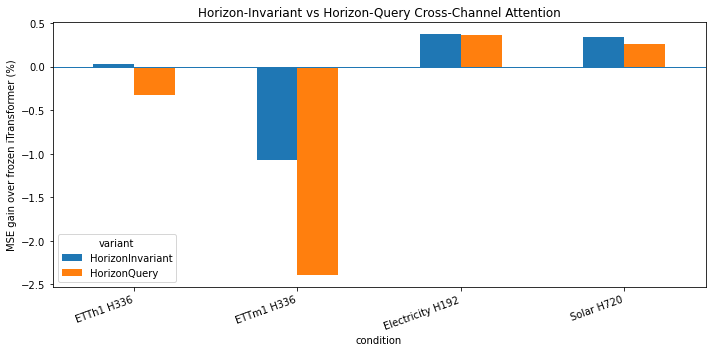

In [18]:
plot_df = (
    results_df[
        [
            "dataset",
            "pred_len",
            "variant",
            "mse_gain_vs_iTransformer_%",
        ]
    ]
    .copy()
)

plot_df[
    "condition"
] = (
    plot_df[
        "dataset"
    ]
    +
    " H"
    +
    plot_df[
        "pred_len"
    ].astype(
        str
    )
)

plot_pivot = plot_df.pivot(
    index="condition",
    columns="variant",
    values="mse_gain_vs_iTransformer_%",
)

ax = plot_pivot.plot(
    kind="bar",
    figsize=(
        10,
        5,
    ),
)

ax.axhline(
    0.0,
    linewidth=1,
)

ax.set_ylabel(
    "MSE gain over frozen iTransformer (%)"
)

ax.set_title(
    "Horizon-Invariant vs Horizon-Query Cross-Channel Attention"
)

plt.xticks(
    rotation=20,
    ha="right",
)

plt.tight_layout()
plt.show()


# 17. Decision rule

This section implements the matched horizon-specific topology-transfer mechanism. Predictive-utility source sets are computed from training data and then imposed on the neural forecaster as specified in the paper.
